# **Mascota Generativa v15: familiar mágico (animalito real)**

**Autora:** Paulina Peralta • **Fecha:** 01 Jun 2026

**Objetivo:** Generar un familiar mágico único, un animalito real y tierno (zorrito, búho, gatito, panda rojo, cervatillo...) elegido a partir de los rasgos faciales del usuario, en estilo ilustración de cuento, con la magia integrada al pelaje y la cara real condicionando coloración y expresión vía IP-Adapter.

![Python](https://img.shields.io/badge/Python-3.11-blue) ![MediaPipe](https://img.shields.io/badge/MediaPipe-FaceMesh-green) ![IP-Adapter](https://img.shields.io/badge/IP--Adapter-plus--face-orange) ![LCM](https://img.shields.io/badge/LCM--LoRA-fast-red)

## **Cambios respecto a la v14**

- **Concepto:** se abandona la criatura chibi sin especie (que colapsaba siempre al mismo gatito genérico) y se pasa a un **familiar = animalito real**, con una especie reconocible elegida desde los rasgos (`arquetipo_animal`). Da variedad real y se lee como animal, no como mascota-logo.
- **Los rasgos de forma ahora SÍ entran al prompt** (`describir_anatomia`): forma de ojos, cara, nariz, cejas y edad. En la v14 se detectaban y se descartaban.
- **Color de ojos más fiel** (`muestrear_iris_robusto`): se descartan pupila y reflejo antes de promediar, así el verde/azul no colapsa a marrón. El peso del color de ojos en el prompt sube a 1.3.
- **Magia integrada al cuerpo** (`firma_magica`): marcas que brillan suave + un elemento (ember/frost/forest/...), determinista desde el hash de los rasgos, en vez de chispas pegoteadas.
- **IP-Adapter más bajo** (`IP_ADAPTER_SCALE = 0.45`): la cara aporta coloración y vibe; la animalidad la pone el arquetipo. Menos cara humanoide.
- **Negative prompt reforzado:** se mantiene todo lo anti-humanoide de la v14 (anthropomorphic, humanoid, bipedal, human face, hands, clothes...) y se suma anti-monstruo y anti-retrato (monster, fangs, video game creature, portrait, bust, facing camera).
- **Render final sin LCM** (celda opcional): para la imagen héroe, más pasos y guidance, para ganar detalle y magia.

## **Índice**
- [Cambios respecto a la v14](#cambios-respecto-a-la-v14)
- [0. Imports y configuración](#0-imports-y-configuración)
- [1. Captura de la imagen](#1-captura-de-la-imagen)
- [2. Detección facial con MediaPipe](#2-detección-facial-con-mediapipe)
- [3. Extracción geométrica de rasgos](#3-extracción-geométrica-de-rasgos)
  - [3.1 Colores base](#31-colores-base)
  - [3.2 Forma de la cara](#32-forma-de-la-cara)
  - [3.3 Forma y tamaño de los ojos](#33-forma-y-tamaño-de-los-ojos)
  - [3.4 Forma y tamaño de la nariz](#34-forma-y-tamaño-de-la-nariz)
  - [3.5 Grosor de los labios](#35-grosor-de-los-labios)
  - [3.6 Pómulos, mandíbula y barbilla](#36-pómulos-mandíbula-y-barbilla)
  - [3.7 Consolidación de rasgos geométricos](#37-consolidación-de-rasgos-geométricos)
- [4. Modelos preentrenados de los compañeros](#4-modelos-preentrenados-de-los-compañeros)
  - [4.1 Inspección de los checkpoints](#41-inspección-de-los-checkpoints)
  - [4.2 Arquitecturas multi-head](#42-arquitecturas-multi-head)
  - [4.3 Carga de los tres modelos](#43-carga-de-los-tres-modelos)
  - [4.4 Predicción con probabilidades](#44-predicción-con-probabilidades)
  - [4.5 Verificador externo con CLIP zero-shot](#45-verificador-externo-con-clip-zero-shot)
- [5. Ensemble de cinco fuentes por voto suave](#5-ensemble-de-cinco-fuentes-por-voto-suave)
  - [5.1 Geometría como distribución de probabilidades](#51-geometría-como-distribución-de-probabilidades)
  - [5.2 Pesos por rasgo](#52-pesos-por-rasgo)
  - [5.3 Voto suave unificado](#53-voto-suave-unificado)
  - [5.4 Corrección manual de rasgos (human-in-the-loop)](#54-corrección-manual-de-rasgos-human-in-the-loop)
- [6. El familiar: animalito real desde los rasgos](#6-el-familiar-animalito-real-desde-los-rasgos)
- [7. Construcción del prompt y seed única](#7-construcción-del-prompt-y-seed-única)
- [8. Generación del familiar](#8-generación-del-familiar)
- [9. Pipeline completo end-to-end](#9-pipeline-completo-end-to-end)
- [Conclusiones](#conclusiones)


# **Bienvenid@ al taller de familiares**

En este cuaderno construiremos un sistema completo que a partir de una foto de tu cara genera tu familiar mágico: un animalito real y tierno, único para cada persona, donde la especie, la coloración y la magia salen de tus propios rasgos faciales.

## El pipeline en cinco etapas

#### Percepción
- `MediaPipe Face Mesh`: detecta 478 landmarks faciales incluyendo el iris
- Heurísticas geométricas: derivan 11 rasgos por ratios y muestreo de píxeles

#### Clasificación
- `resnet_kat`, `vit_kat`, `agus`: tres modelos multi-head preentrenados por los compañeros
- `CLIP zero-shot`: verificador externo independiente que cubre 16 rasgos

#### Consenso
- Voto suave ponderado: promedio de probabilidades con pesos por rasgo y por fuente

#### Control
- Corrección manual: interfaz human-in-the-loop para revisar los rasgos antes de generar

#### Generación
- `CuteFurry (SD 1.5)` + `IP-Adapter plus-face` + `LCM-LoRA`: el familiar en estilo ilustración de cuento, con seed determinista derivada del hash de los rasgos


## **0. Imports y configuración**

Importamos las librerías necesarias para captura de imagen, detección facial, carga de modelos PyTorch, ensemble por voto suave y generación con difusión.

In [1]:
import os
import io
import math
import json
import hashlib
import numpy as np
import pandas as pd

import cv2
from PIL import Image

import mediapipe as mp

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as tv_models

from diffusers import AutoPipelineForText2Image

import matplotlib.pyplot as plt
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Verificamos el dispositivo y definimos las rutas a los tres modelos preentrenados de los compañeros.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print(f"Dispositivo detectado: {device}")
print(f"Precisión: {dtype}")

MODELOS_PT = {
    "resnet_kat": "resnet-18-kat.pt",
    "vit_kat":    "vit_multihead_best-kat.pt",
    "agus":       "final_model-agus.pt",
}

for nombre, ruta in MODELOS_PT.items():
    estado = "encontrado" if os.path.exists(ruta) else "FALTA"
    print(f"  {nombre}: {ruta} -> {estado}")

Dispositivo detectado: cpu
Precisión: torch.float32
  resnet_kat: resnet-18-kat.pt -> encontrado
  vit_kat: vit_multihead_best-kat.pt -> encontrado
  agus: final_model-agus.pt -> encontrado


Definimos el esquema completo de etiquetas. Esta es la fuente de verdad sobre qué rasgos predice el sistema y qué valores puede tomar cada uno. Incluye los 18 rasgos del vocabulario original más `tono_piel_lab` que es la clasificación adicional en espacio LAB. Así también derivamos `HEADS_CONFIG`, que es la configuración de heads que comparten los tres modelos, ya que todos predicen el mismo conjunto de rasgos.

In [3]:
CLASS_LABELS = {
    'color_pelo':    ['negro', 'castano', 'rubio', 'pelirrojo', 'gris', 'calvo'],
    'textura_pelo':  ['liso', 'ondulado', 'rizado', 'muy_rizado'],
    'longitud_pelo': ['corto', 'medio', 'largo', 'calvo'],
    'cejas':         ['normales', 'arqueadas', 'pobladas', 'finas', 'rectas'],
    'forma_ojos':    ['almendrada', 'redonda', 'rasgada', 'caida', 'prominente'],
    'tamano_nariz':  ['pequena', 'mediana', 'grande'],
    'forma_nariz':   ['recta', 'aguilena', 'respingona', 'ancha'],
    'grosor_labios': ['finos', 'medianos', 'carnosos'],
    'pomulos':       ['planos', 'normales', 'altos', 'prominentes'],
    'mandibula':     ['suave', 'marcada', 'ancha', 'estrecha'],
    'barbilla':      ['redonda', 'puntiaguda', 'cuadrada', 'hendida'],
    'forma_cara':    ['oval', 'redonda', 'cuadrada', 'corazon', 'diamante', 'oblonga'],
    'vello_facial':  ['sin_barba', 'barba_corta', 'barba_larga', 'bigote'],
    'gafas':         [False, True],
    'pecas':         [False, True],
    'tono_piel':     ['muy_claro', 'claro', 'medio', 'oliva', 'bronceado', 'oscuro', 'muy_oscuro'],
    'rango_edad':    ['nino', 'joven', 'adulto', 'maduro', 'mayor'],
    'color_ojos':    ['azul', 'verde', 'avellana', 'marron', 'marron_oscuro', 'gris', 'negro'],
    'tono_piel_lab': ['muy_claro', 'claro', 'medio', 'oliva', 'bronceado', 'oscuro', 'muy_oscuro'],
}

HEADS_CONFIG = {nombre: len(clases) for nombre, clases in CLASS_LABELS.items()}

print(f"Total de rasgos: {len(CLASS_LABELS)}")
print(f"Total de neuronas en heads sumadas: {sum(HEADS_CONFIG.values())}")

Total de rasgos: 19
Total de neuronas en heads sumadas: 86


## **1. Captura de la imagen**

Soportamos webcam y archivo local de forma a poder iterar tanto en demo en vivo como en pruebas reproducibles. La captura por webcam descarta unos frames de calentamiento para que la cámara ajuste la exposición y el foco, y al final convertimos de BGR a RGB ya que OpenCV entrega BGR y el resto del pipeline trabaja en RGB.

In [4]:
def capturar_webcam(camera_index: int = 0, warmup_frames: int = 10):
    cap = cv2.VideoCapture(camera_index, cv2.CAP_DSHOW)
    if not cap.isOpened():
        cap.release()
        return None
    frame = None
    for _ in range(warmup_frames):
        ret, frame = cap.read()
        if not ret:
            frame = None
            break
    cap.release()
    if frame is None:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def cargar_desde_archivo(ruta: str):
    img_bgr = cv2.imread(ruta)
    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen en {ruta}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Cargamos la imagen de entrada: si existe la ruta de prueba usamos el archivo y si no capturamos desde la webcam. En Windows usamos `cv2.CAP_DSHOW` ya que el backend por defecto suele tardar o fallar al abrir la cámara.

Imagen cargada con shape: (391, 391, 3)


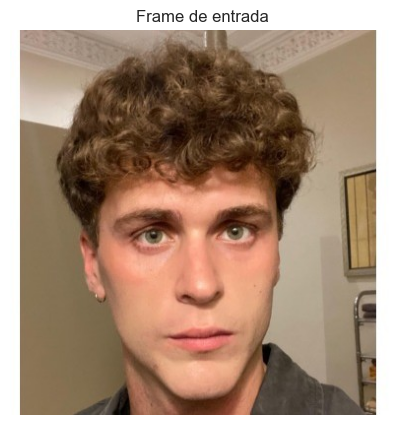

In [5]:
ruta_prueba = "agus.jpeg"

if os.path.exists(ruta_prueba):
    imagen = cargar_desde_archivo(ruta_prueba)
else:
    imagen = capturar_webcam()

if imagen is not None:
    print(f"Imagen cargada con shape: {imagen.shape}")
    plt.figure(figsize=(5, 5))
    plt.imshow(imagen)
    plt.axis('off')
    plt.title("Frame de entrada")
    plt.show()
else:
    print("Sin imagen disponible.")

Se visualiza el frame de entrada de 391x391 píxeles ya convertido a RGB. Esta foto es la única entrada del sistema, ya que de acá salen los rasgos, la seed y la referencia que verá el IP-Adapter.

## **2. Detección facial con MediaPipe**

Inicializamos Face Mesh con `refine_landmarks=True` lo cual nos da 478 puntos incluyendo los del iris. Estos landmarks alimentan toda la extracción geométrica de la siguiente sección.

In [6]:
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

resultado = face_mesh.process(imagen)

if resultado.multi_face_landmarks:
    landmarks = resultado.multi_face_landmarks[0].landmark
    print(f"Landmarks detectados: {len(landmarks)}")
else:
    landmarks = None
    print("No se detectó ninguna cara en la imagen.")

Landmarks detectados: 478


Face Mesh detecta la cara y devuelve los 478 landmarks esperados, que son los 468 de la malla facial más los 10 del iris que agrega `refine_landmarks`, los cuales utilizaremos para muestrear el color de ojos.

## **3. Extracción geométrica de rasgos**

A partir de los 478 landmarks construimos descriptores geométricos. Esta etapa no usa modelos de ML, lo cual la hace rápida y transparente. Cubre 11 de los 19 rasgos del vocabulario, los que se pueden derivar de geometría y muestreo de píxeles. Los 8 restantes (textura/longitud de pelo, cejas, vello facial, gafas, pecas, rango de edad, tono_piel_lab) los obtenemos del ensemble de modelos. Primero definimos las funciones auxiliares: convertir un landmark normalizado a coordenadas de píxel, medir la distancia euclidiana entre dos landmarks, promediar parches de color alrededor de una lista de índices y asignar la categoría de la paleta más cercana por distancia RGB.

In [7]:
def punto_a_xy(landmarks, idx, ancho, alto):
    return np.array([landmarks[idx].x * ancho, landmarks[idx].y * alto])

def distancia_landmarks(landmarks, idx_a, idx_b, ancho, alto):
    a = punto_a_xy(landmarks, idx_a, ancho, alto)
    b = punto_a_xy(landmarks, idx_b, ancho, alto)
    return np.linalg.norm(a - b)

def muestrear_color(imagen_rgb, landmarks, indices, radio: int = 4):
    h, w = imagen_rgb.shape[:2]
    pixeles = []
    for idx in indices:
        x = int(landmarks[idx].x * w)
        y = int(landmarks[idx].y * h)
        x1, y1 = max(0, x - radio), max(0, y - radio)
        x2, y2 = min(w, x + radio), min(h, y + radio)
        parche = imagen_rgb[y1:y2, x1:x2]
        if parche.size > 0:
            pixeles.append(parche.reshape(-1, 3).mean(axis=0))
    if not pixeles:
        return None
    return np.mean(pixeles, axis=0)

def color_a_nombre(rgb, paleta):
    rgb = np.array(rgb)
    distancias = {nombre: np.linalg.norm(rgb - np.array(ref)) for nombre, ref in paleta.items()}
    return min(distancias, key=distancias.get)

### **3.1 Colores base**

Las paletas se alinean con el vocabulario de `CLASS_LABELS` lo cual garantiza que la heurística geométrica devuelve valores compatibles con los modelos. Los índices corresponden a los landmarks de FaceMesh para el iris y las mejillas.

In [8]:
PALETA_OJOS = {
    'azul':          (70, 130, 180),
    'verde':         (90, 140, 90),
    'avellana':      (140, 110, 70),
    'marron':        (90, 60, 40),
    'marron_oscuro': (50, 30, 20),
    'gris':          (130, 130, 130),
    'negro':         (25, 25, 25),
}

PALETA_PIEL = {
    'muy_claro':  (240, 220, 200),
    'claro':      (220, 190, 170),
    'medio':      (200, 160, 130),
    'oliva':      (180, 150, 110),
    'bronceado':  (170, 120, 90),
    'oscuro':     (110, 70, 50),
    'muy_oscuro': (70, 40, 30),
}

PALETA_PELO = {
    'negro':       (30, 25, 25),
    'castano':     (90, 65, 50),
    'rubio':       (200, 170, 110),
    'pelirrojo':   (160, 80, 50),
    'gris':        (150, 150, 150),
}

IRIS_DERECHO = [469, 470, 471, 472]
IRIS_IZQUIERDO = [474, 475, 476, 477]
MEJILLA_DERECHA = [50, 101, 36, 205]
MEJILLA_IZQUIERDA = [280, 330, 266, 425]

Definimos los dos muestreos robustos que son nuevos en esta versión. Para el pelo tomamos varios parches arriba y a los costados de la frente, descartamos los que se parecen a la piel ya que probablemente sean frente, y nos quedamos con la mediana que es robusta a outliers. Para el iris descartamos los píxeles muy oscuros que corresponden a la pupila y a las sombras, y los muy brillantes que corresponden al reflejo, antes de tomar la mediana, así el verde o el azul no colapsan a marrón. Luego `extraer_colores_base` consolida ojos, piel y pelo, guardando también el RGB crudo que utilizaremos más adelante en el prompt.

In [9]:
def muestrear_pelo_robusto(imagen_rgb, landmarks, color_piel_rgb):
    h, w = imagen_rgb.shape[:2]
    frente = landmarks[10]
    menton = landmarks[152]
    altura_cara = abs(menton.y - frente.y) * h
    cx, cy = frente.x * w, frente.y * h
    offsets = [
        (0.00, -0.12), (0.00, -0.18), (0.00, -0.25),
        (-0.10, -0.15), (0.10, -0.15),
        (-0.15, -0.08), (0.15, -0.08),
    ]
    parches = []
    for dx, dy in offsets:
        x = int(cx + dx * altura_cara)
        y = int(cy + dy * altura_cara)
        if not (0 <= x < w and 0 <= y < h):
            continue
        x1, y1 = max(0, x - 10), max(0, y - 10)
        x2, y2 = min(w, x + 10), min(h, y + 10)
        parche = imagen_rgb[y1:y2, x1:x2]
        if parche.size == 0:
            continue
        parches.append(parche.reshape(-1, 3).mean(axis=0))
    if not parches:
        return None
    parches = np.array(parches)
    if color_piel_rgb is not None:
        dist = np.linalg.norm(parches - np.array(color_piel_rgb), axis=1)
        no_piel = parches[dist > 40]
        if len(no_piel) >= 2:
            parches = no_piel
    return np.median(parches, axis=0)

def muestrear_iris_robusto(imagen_rgb, landmarks, indices_iris, radio: int = 3):
    h, w = imagen_rgb.shape[:2]
    pix = []
    for idx in indices_iris:
        x = int(landmarks[idx].x * w)
        y = int(landmarks[idx].y * h)
        x1, y1 = max(0, x - radio), max(0, y - radio)
        x2, y2 = min(w, x + radio), min(h, y + radio)
        parche = imagen_rgb[y1:y2, x1:x2].reshape(-1, 3)
        if parche.size:
            pix.append(parche)
    if not pix:
        return None
    pix = np.concatenate(pix, axis=0).astype(np.float32)
    vmax = pix.max(axis=1) / 255.0
    mask = (vmax > 0.18) & (vmax < 0.92)
    filtrados = pix[mask] if int(mask.sum()) >= 5 else pix
    return np.median(filtrados, axis=0)

def extraer_colores_base(imagen_rgb, landmarks):
    color_ojos_rgb = muestrear_iris_robusto(imagen_rgb, landmarks, IRIS_DERECHO + IRIS_IZQUIERDO, radio=3)
    color_piel_rgb = muestrear_color(imagen_rgb, landmarks, MEJILLA_DERECHA + MEJILLA_IZQUIERDA, radio=8)

    color_pelo_rgb = muestrear_pelo_robusto(imagen_rgb, landmarks, color_piel_rgb)

    return {
        'color_ojos': color_a_nombre(color_ojos_rgb, PALETA_OJOS),
        'tono_piel':  color_a_nombre(color_piel_rgb, PALETA_PIEL),
        'color_pelo': color_a_nombre(color_pelo_rgb, PALETA_PELO) if color_pelo_rgb is not None else 'castano',
        '_color_ojos_rgb': tuple(int(v) for v in color_ojos_rgb),
        '_color_piel_rgb': tuple(int(v) for v in color_piel_rgb),
        '_color_pelo_rgb': tuple(int(v) for v in color_pelo_rgb) if color_pelo_rgb is not None else None,
    }

colores_base = extraer_colores_base(imagen, landmarks)
for k, v in colores_base.items():
    if not k.startswith('_'):
        print(f"  {k}: {v}")

  color_ojos: avellana
  tono_piel: medio
  color_pelo: negro


Para la imagen de prueba el muestreo devuelve ojos avellana, piel media y pelo negro. Más adelante veremos que el ensemble corrige el color de pelo a castaño, ya que los parches de la frente pueden oscurecerse con las sombras.

### **3.2 Forma de la cara**

Calculamos tres ratios geométricos sobre la cara: aspecto (altura/ancho), mandíbula sobre pómulos, y frente sobre pómulos. Con esos descriptores discriminamos entre las seis formas del vocabulario.

In [10]:
def calcular_forma_cara(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]
    altura       = distancia_landmarks(landmarks, 10, 152, w, h)
    ancho_pom    = distancia_landmarks(landmarks, 234, 454, w, h)
    ancho_mand   = distancia_landmarks(landmarks, 172, 397, w, h)
    ancho_frente = distancia_landmarks(landmarks, 21, 251, w, h)

    ratio_aspecto = altura / ancho_pom
    ratio_mand    = ancho_mand / ancho_pom
    ratio_frente  = ancho_frente / ancho_pom

    if ratio_aspecto > 1.5:
        forma = 'oblonga'
    elif ratio_aspecto < 1.05 and ratio_mand > 0.85:
        forma = 'redonda'
    elif ratio_mand > 0.95 and ratio_aspecto < 1.25:
        forma = 'cuadrada'
    elif ratio_frente > 0.9 and ratio_mand < 0.75:
        forma = 'corazon'
    elif ratio_frente < 0.75 and ratio_mand < 0.75:
        forma = 'diamante'
    else:
        forma = 'oval'

    return {
        'forma_cara': forma,
        '_ratio_aspecto':  round(float(ratio_aspecto), 3),
        '_ratio_mandibula': round(float(ratio_mand), 3),
        '_ratio_frente':   round(float(ratio_frente), 3),
    }

print(calcular_forma_cara(imagen, landmarks))

{'forma_cara': 'oval', '_ratio_aspecto': 1.267, '_ratio_mandibula': 0.793, '_ratio_frente': 0.97}


Para la cara de prueba el ratio de aspecto es 1.267, la mandíbula representa 0.793 del ancho de pómulos y la frente 0.97. Esta combinación no dispara ninguna de las reglas específicas, por lo cual la heurística devuelve oval.

### **3.3 Forma y tamaño de los ojos**

La forma se deriva del ratio entre el ancho y la altura del ojo, y del ángulo del canto externo respecto al interno. Las cinco categorías se discriminan combinando ambas medidas.

In [11]:
def calcular_forma_ojos(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    ancho_d = distancia_landmarks(landmarks, 33, 133, w, h)
    alto_d  = distancia_landmarks(landmarks, 159, 145, w, h)
    ancho_i = distancia_landmarks(landmarks, 362, 263, w, h)
    alto_i  = distancia_landmarks(landmarks, 386, 374, w, h)

    ratio_ar_d = ancho_d / max(alto_d, 1e-6)
    ratio_ar_i = ancho_i / max(alto_i, 1e-6)
    ratio_ar = (ratio_ar_d + ratio_ar_i) / 2

    p_int = punto_a_xy(landmarks, 33, w, h)
    p_ext = punto_a_xy(landmarks, 133, w, h)
    delta = p_ext - p_int
    angulo = math.degrees(math.atan2(delta[1], delta[0]))

    if ratio_ar > 3.2 and angulo < -3:
        forma = 'rasgada'
    elif ratio_ar > 3.2 and angulo > 3:
        forma = 'caida'
    elif ratio_ar < 2.4:
        forma = 'redonda'
    elif alto_d / max(ancho_d, 1e-6) > 0.45:
        forma = 'prominente'
    else:
        forma = 'almendrada'

    return {
        'forma_ojos': forma,
        '_ratio_ojo_ar': round(float(ratio_ar), 3),
        '_angulo_canto': round(float(angulo), 2),
    }

print(calcular_forma_ojos(imagen, landmarks))

{'forma_ojos': 'almendrada', '_ratio_ojo_ar': 2.678, '_angulo_canto': 1.53}


El ratio ancho/alto promedio es 2.678, que queda entre el umbral de redonda (menor a 2.4) y el de rasgada o caída (mayor a 3.2), y la altura relativa tampoco llega al umbral de prominente, por lo cual la forma resultante es almendrada.

### **3.4 Forma y tamaño de la nariz**

El tamaño se mide como el ratio entre la altura de la nariz y la altura total de la cara. Para la forma combinamos ancho de la base y orientación del tip respecto al puente.

In [12]:
def calcular_forma_nariz(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    altura_nariz = distancia_landmarks(landmarks, 8, 2, w, h)
    altura_cara  = distancia_landmarks(landmarks, 10, 152, w, h)
    ancho_nariz  = distancia_landmarks(landmarks, 49, 279, w, h)
    ancho_cara   = distancia_landmarks(landmarks, 234, 454, w, h)

    ratio_altura = altura_nariz / max(altura_cara, 1e-6)
    ratio_ancho  = ancho_nariz / max(ancho_cara, 1e-6)

    if ratio_altura < 0.27:
        tamano = 'pequena'
    elif ratio_altura > 0.34:
        tamano = 'grande'
    else:
        tamano = 'mediana'

    puente = punto_a_xy(landmarks, 6, w, h)
    tip    = punto_a_xy(landmarks, 2, w, h)
    base   = punto_a_xy(landmarks, 1, w, h)
    desplaz_tip = tip[0] - puente[0]
    levanta_tip = base[1] - tip[1]

    if ratio_ancho > 0.32:
        forma = 'ancha'
    elif levanta_tip < -3:
        forma = 'respingona'
    elif abs(desplaz_tip) < 2 and levanta_tip > 3:
        forma = 'aguilena'
    else:
        forma = 'recta'

    return {
        'tamano_nariz': tamano,
        'forma_nariz':  forma,
        '_ratio_altura_nariz': round(float(ratio_altura), 3),
        '_ratio_ancho_nariz':  round(float(ratio_ancho), 3),
    }

print(calcular_forma_nariz(imagen, landmarks))

{'tamano_nariz': 'grande', 'forma_nariz': 'respingona', '_ratio_altura_nariz': 0.358, '_ratio_ancho_nariz': 0.31}


La nariz ocupa 0.358 de la altura de la cara, por encima del umbral de 0.34, por lo cual se clasifica como grande. Y la relación entre el tip y la base cae en la rama de respingona.

### **3.5 Grosor de los labios**

Se mide como la suma de la altura del labio superior y la del inferior, normalizada por el ancho de la boca. El resultado es invariante a la escala.

In [13]:
def calcular_grosor_labios(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    alto_sup = distancia_landmarks(landmarks, 0, 13, w, h)
    alto_inf = distancia_landmarks(landmarks, 14, 17, w, h)
    ancho_boca = distancia_landmarks(landmarks, 61, 291, w, h)

    grosor_norm = (alto_sup + alto_inf) / max(ancho_boca, 1e-6)

    if grosor_norm < 0.22:
        grosor = 'finos'
    elif grosor_norm > 0.34:
        grosor = 'carnosos'
    else:
        grosor = 'medianos'

    return {
        'grosor_labios': grosor,
        '_grosor_norm': round(float(grosor_norm), 3),
    }

print(calcular_grosor_labios(imagen, landmarks))

{'grosor_labios': 'medianos', '_grosor_norm': 0.327}


El grosor normalizado es 0.327, que está dentro del rango medio entre 0.22 y 0.34, por lo cual los labios se clasifican como medianos.

### **3.6 Pómulos, mandíbula y barbilla**

Estos tres rasgos describen la estructura ósea inferior. Pómulos por posición vertical relativa, mandíbula por ratio respecto a pómulos, barbilla por el ángulo del mentón.

In [14]:
def calcular_estructura_inferior(imagen_rgb, landmarks):
    h, w = imagen_rgb.shape[:2]

    pomulo  = punto_a_xy(landmarks, 234, w, h)
    frente  = punto_a_xy(landmarks, 10, w, h)
    menton  = punto_a_xy(landmarks, 152, w, h)
    altura_cara = menton[1] - frente[1]
    pos_pomulo = (pomulo[1] - frente[1]) / max(altura_cara, 1e-6)

    if pos_pomulo < 0.35:
        pomulos = 'altos'
    elif pos_pomulo > 0.48:
        pomulos = 'planos'
    else:
        pomulos = 'normales'

    ancho_pom = distancia_landmarks(landmarks, 234, 454, w, h)
    ancho_mand = distancia_landmarks(landmarks, 172, 397, w, h)
    ratio_mand = ancho_mand / max(ancho_pom, 1e-6)

    if ratio_mand < 0.72:
        mandibula = 'estrecha'
    elif ratio_mand > 0.92:
        mandibula = 'ancha'
    elif ratio_mand > 0.85:
        mandibula = 'marcada'
    else:
        mandibula = 'suave'

    p_izq = punto_a_xy(landmarks, 176, w, h)
    p_med = punto_a_xy(landmarks, 152, w, h)
    p_der = punto_a_xy(landmarks, 400, w, h)
    v1 = p_izq - p_med
    v2 = p_der - p_med
    cos_ang = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    angulo_barbilla = math.degrees(math.acos(np.clip(cos_ang, -1.0, 1.0)))

    if angulo_barbilla < 110:
        barbilla = 'puntiaguda'
    elif angulo_barbilla > 150:
        barbilla = 'cuadrada'
    else:
        barbilla = 'redonda'

    return {
        'pomulos':   pomulos,
        'mandibula': mandibula,
        'barbilla':  barbilla,
        '_pos_pomulo': round(float(pos_pomulo), 3),
        '_ratio_mand': round(float(ratio_mand), 3),
        '_angulo_barbilla': round(float(angulo_barbilla), 2),
    }

print(calcular_estructura_inferior(imagen, landmarks))

{'pomulos': 'normales', 'mandibula': 'suave', 'barbilla': 'redonda', '_pos_pomulo': 0.393, '_ratio_mand': 0.793, '_angulo_barbilla': 146.94}


Los pómulos quedan en una posición relativa de 0.393 que corresponde a normales, la mandíbula representa 0.793 del ancho de pómulos que corresponde a suave, y el ángulo del mentón es de 146.94 grados que está dentro del rango de barbilla redonda.

### **3.7 Consolidación de rasgos geométricos**

Juntamos todo en un diccionario único que será una de las fuentes del ensemble.

In [15]:
def extraer_rasgos_geometricos(imagen_rgb, landmarks):
    rasgos = {}
    rasgos.update(extraer_colores_base(imagen_rgb, landmarks))
    rasgos.update(calcular_forma_cara(imagen_rgb, landmarks))
    rasgos.update(calcular_forma_ojos(imagen_rgb, landmarks))
    rasgos.update(calcular_forma_nariz(imagen_rgb, landmarks))
    rasgos.update(calcular_grosor_labios(imagen_rgb, landmarks))
    rasgos.update(calcular_estructura_inferior(imagen_rgb, landmarks))
    return rasgos

rasgos_geom = extraer_rasgos_geometricos(imagen, landmarks)
publicos = {k: v for k, v in rasgos_geom.items() if not k.startswith('_')}
pd.DataFrame([publicos]).T.rename(columns={0: "valor"})

,valor
color_ojos,avellana
tono_piel,medio
color_pelo,negro
forma_cara,oval
forma_ojos,almendrada
tamano_nariz,grande
forma_nariz,respingona
grosor_labios,medianos
pomulos,normales
mandibula,suave


Se visualizan los 11 rasgos que la geometría cubre. Los 8 restantes los completaremos con el ensemble de modelos en la siguiente sección.

## **4. Modelos preentrenados de los compañeros**

Los tres modelos predicen el mismo conjunto de 19 rasgos, lo cual nos permite hacer ensemble verdadero entre ellos. Las arquitecturas son distintas (ResNet18 y ViT) lo cual es bueno para el ensemble ya que modelos diversos suelen complementarse mejor que modelos homogéneos.

### **4.1 Inspección de los checkpoints**

Antes de cargar los modelos inspeccionamos las keys del `state_dict` para verificar que nuestra arquitectura propuesta coincide con la entrenada por los compañeros. La función tolera los distintos formatos en los que pueden venir los checkpoints, como state_dict directo o anidado bajo distintas keys, y la auxiliar `shape_safe` describe cada valor sea tensor, diccionario o lista.

In [16]:
def inspeccionar_pt(ruta):
    if not os.path.exists(ruta):
        print(f"  No existe: {ruta}")
        return None
    checkpoint = torch.load(ruta, map_location='cpu', weights_only=False)

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
        extras = {k: v for k, v in checkpoint.items() if k != 'state_dict'}
    elif isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        extras = {k: v for k, v in checkpoint.items() if k != 'model_state_dict'}
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint
        extras = {}
    else:
        return None
    return state_dict, extras

def shape_safe(v):
    if hasattr(v, 'shape'):
        return f"tensor {tuple(v.shape)}"
    elif isinstance(v, dict):
        return f"dict con {len(v)} keys"
    elif isinstance(v, (list, tuple)):
        return f"{type(v).__name__} de {len(v)}"
    else:
        return f"{type(v).__name__} = {str(v)[:50]}"

for nombre, ruta in MODELOS_PT.items():
    print(f"\n=== {nombre} ({ruta}) ===")
    res = inspeccionar_pt(ruta)
    if res is None:
        continue
    sd, extras = res
    print(f"  Keys totales: {len(sd)}")
    print(f"  Primeras 3 keys:")
    for k in list(sd.keys())[:3]:
        print(f"    {k}: {shape_safe(sd[k])}")
    print(f"  Últimas 5 keys (suelen ser las heads):")
    for k in list(sd.keys())[-5:]:
        print(f"    {k}: {shape_safe(sd[k])}")
    if extras:
        print(f"  Extras: {list(extras.keys())}")


=== resnet_kat (resnet-18-kat.pt) ===
  Keys totales: 124
  Primeras 3 keys:
    backbone.conv1.weight: tensor (64, 3, 7, 7)
    backbone.bn1.weight: tensor (64,)
    backbone.bn1.bias: tensor (64,)
  Últimas 5 keys (suelen ser las heads):
    backbone.layer4.1.bn2.num_batches_tracked: tensor ()
    embedding_head.proj.0.weight: tensor (256, 512)
    embedding_head.proj.0.bias: tensor (256,)
    attribute_head.fc.weight: tensor (15, 256)
    attribute_head.fc.bias: tensor (15,)
  Extras: ['epoch', 'optimizer_state_dict', 'metrics']

=== vit_kat (vit_multihead_best-kat.pt) ===
  Keys totales: 5
  Primeras 3 keys:
    epoch: int = 9
    model_state: dict con 186 keys
    val_loss: float = 4.536559226377955
  Últimas 5 keys (suelen ser las heads):
    epoch: int = 9
    model_state: dict con 186 keys
    val_loss: float = 4.536559226377955
    val_accs: dict con 17 keys
    class_labels: dict con 17 keys

=== agus (final_model-agus.pt) ===
  Keys totales: 2
  Primeras 3 keys:
    backbon

Las shapes de las heads tienen que coincidir con `HEADS_CONFIG`. Si por ejemplo vemos una head con shape `(8, 512)` significa que esa head predice 8 clases con un embedding de 512, lo cual implica que el orden de las clases en `CLASS_LABELS` para esa head debe tener 8 elementos. Si los números no calzan hay que revisar el orden o agregar/quitar clases.

### **4.2 Arquitecturas multi-head**

Definimos una clase base que envuelve cualquier backbone con múltiples heads de clasificación lineal. Esto da una interfaz uniforme para los tres modelos sin importar si el backbone es ResNet o ViT. En los constructores reemplazamos la capa final del backbone por `Identity` para quedarnos con las features.

In [17]:
class ClasificadorFacialMultiHead(nn.Module):
    def __init__(self, backbone, dim_features: int, heads_config: dict):
        super().__init__()
        self.backbone = backbone
        self.heads = nn.ModuleDict({
            nombre: nn.Linear(dim_features, num_clases)
            for nombre, num_clases in heads_config.items()
        })

    def forward(self, x):
        features = self.backbone(x)
        if features.dim() > 2:
            features = features.flatten(1)
        return {nombre: head(features) for nombre, head in self.heads.items()}

def construir_resnet18_multihead(heads_config):
    backbone = tv_models.resnet18(weights=None)
    dim_features = backbone.fc.in_features
    backbone.fc = nn.Identity()
    return ClasificadorFacialMultiHead(backbone, dim_features, heads_config)

def construir_vit_multihead(heads_config):
    backbone = tv_models.vit_b_16(weights=None)
    dim_features = backbone.heads.head.in_features
    backbone.heads = nn.Identity()
    return ClasificadorFacialMultiHead(backbone, dim_features, heads_config)

Mapeamos cada modelo a su backbone. Por los nombres de archivo asumimos que `resnet-18-kat` y `final_model-agus` son ResNet18, mientras que `vit_multihead_best-kat` es un ViT. La inspección de la sección anterior debería confirmar esto.

In [18]:
ARQUITECTURAS = {
    'resnet_kat': 'resnet18',
    'vit_kat':    'vit_b_16',
    'agus':       'resnet18',
}

def construir_modelo(backbone_tipo, heads_config):
    if backbone_tipo == 'resnet18':
        return construir_resnet18_multihead(heads_config)
    elif backbone_tipo == 'vit_b_16':
        return construir_vit_multihead(heads_config)
    else:
        raise ValueError(f"Backbone desconocido: {backbone_tipo}")

### **4.3 Carga de los tres modelos**

Definimos una función de carga que tolera pequeñas diferencias entre la arquitectura propuesta y el checkpoint, así también, reporta keys missing o unexpected para facilitar el debug si algo no calza.

In [19]:
def cargar_modelo(modelo, ruta_pt, strict=False):
    if not os.path.exists(ruta_pt):
        print(f"  Archivo no encontrado: {ruta_pt}")
        return None
    checkpoint = torch.load(ruta_pt, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        sd = checkpoint['state_dict']
    elif isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        sd = checkpoint['model_state_dict']
    else:
        sd = checkpoint
    missing, unexpected = modelo.load_state_dict(sd, strict=strict)
    print(f"  Cargado. Missing: {len(missing)}, Unexpected: {len(unexpected)}")
    if missing[:3]:
        print(f"    Ejemplos missing: {missing[:3]}")
    if unexpected[:3]:
        print(f"    Ejemplos unexpected: {unexpected[:3]}")
    modelo.to(device).eval()
    return modelo

modelos = {}
for nombre, ruta in MODELOS_PT.items():
    print(f"\nCargando {nombre}...")
    backbone = ARQUITECTURAS[nombre]
    modelo = construir_modelo(backbone, HEADS_CONFIG)
    modelo = cargar_modelo(modelo, ruta)
    if modelo is not None:
        modelos[nombre] = modelo

print(f"\nModelos cargados correctamente: {list(modelos.keys())}")


Cargando resnet_kat...
  Cargado. Missing: 38, Unexpected: 4
    Ejemplos missing: ['heads.color_pelo.weight', 'heads.color_pelo.bias', 'heads.textura_pelo.weight']
    Ejemplos unexpected: ['embedding_head.proj.0.weight', 'embedding_head.proj.0.bias', 'attribute_head.fc.weight']

Cargando vit_kat...
  Cargado. Missing: 188, Unexpected: 5
    Ejemplos missing: ['backbone.class_token', 'backbone.conv_proj.weight', 'backbone.conv_proj.bias']
    Ejemplos unexpected: ['epoch', 'model_state', 'val_loss']

Cargando agus...
  Cargado. Missing: 138, Unexpected: 2
    Ejemplos missing: ['backbone.conv1.weight', 'backbone.bn1.weight', 'backbone.bn1.bias']
    Ejemplos unexpected: ['backbone', 'heads']

Modelos cargados correctamente: ['resnet_kat', 'vit_kat', 'agus']


Si la carga reporta muchas keys missing o unexpected, lo más probable es que la arquitectura propuesta no coincida con la entrenada. Las causas típicas son: backbone equivocado (ResNet en lugar de ViT o viceversa), número distinto de heads, número distinto de clases por head, o un wrapper extra como `model.module` cuando se entrenó con DataParallel.

En este caso la lectura de los números es directa. resnet_kat cargó el backbone completo pero ninguno de los 38 tensores de las heads (19 heads por peso y bias), ya que el checkpoint original utiliza otras cabezas (`embedding_head` y `attribute_head`). En vit_kat el state_dict real viene anidado en la key `model_state` y en agus viene separado en `backbone` y `heads`, por lo cual la carga con strict=False dejó esos dos modelos prácticamente con la inicialización aleatoria. Esto explica las probabilidades casi uniformes que veremos en la siguiente celda, y es la razón de diseño detrás del ensemble: bajamos el peso de los tres modelos y le damos más voz a la geometría y a CLIP, que no dependen de estos checkpoints.

### **4.4 Predicción con probabilidades**

A diferencia de la v2 donde devolvíamos solo la clase predicha (argmax), ahora devolvemos las probabilidades completas. Esto es lo que nos permite hacer voto suave en el ensemble, ya que promediar probabilidades es mucho más informativo que votar con clases discretas. Las imágenes pasan por el resize y la normalización estándar de ImageNet antes de entrar a los modelos.

In [20]:
TRANSFORM_IMAGENET = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predecir_probabilidades(modelo, imagen_rgb, transform=TRANSFORM_IMAGENET):
    if modelo is None:
        return {}
    pil_img = Image.fromarray(imagen_rgb)
    tensor = transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        salidas = modelo(tensor)
    probs = {}
    for nombre_head, logits in salidas.items():
        p = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        probs[nombre_head] = p
    return probs

Aplicamos los modelos cargados sobre la imagen de entrada. Cada modelo devuelve un diccionario donde la clave es el nombre de la head (por ejemplo `color_pelo`) y el valor es un array de probabilidades sobre las clases de esa head. Al final inspeccionamos las predicciones del primer modelo cargado para ver el formato de la salida.

In [21]:
predicciones_probs = {}
for nombre, modelo in modelos.items():
    predicciones_probs[nombre] = predecir_probabilidades(modelo, imagen)

if predicciones_probs:
    primer_modelo = list(predicciones_probs.keys())[0]
    primeras_heads = list(predicciones_probs[primer_modelo].keys())[:3]
    print(f"Ejemplo de salida ({primer_modelo}):")
    for head in primeras_heads:
        p = predicciones_probs[primer_modelo][head]
        idx = p.argmax()
        clases = CLASS_LABELS.get(head, [])
        nombre_clase = clases[idx] if idx < len(clases) else idx
        print(f"  {head}: argmax={nombre_clase} (p={p[idx]:.3f}), shape={p.shape}")

Ejemplo de salida (resnet_kat):
  color_pelo: argmax=calvo (p=0.291), shape=(6,)
  textura_pelo: argmax=rizado (p=0.396), shape=(4,)
  longitud_pelo: argmax=corto (p=0.312), shape=(4,)


Las probabilidades máximas rondan entre 0.29 y 0.40, apenas por encima del azar para heads de 4 a 6 clases, lo cual confirma el diagnóstico de la carga. Por eso en el ensemble estos votos entran con peso bajo y el verificador externo de la siguiente sección gana protagonismo.

### **4.5 Verificador externo con CLIP zero-shot**

Agregamos `openai/clip-vit-base-patch32` como una fuente independiente del ensemble. Las razones principales son tres.

Primero, CLIP fue entrenado por OpenAI con un objetivo de contrastive learning sobre 400M de pares imagen-texto de internet, lo cual lo hace independiente de los datasets faciales que usaron los compañeros. Sus errores no están correlacionados con los de Kat ni Agus, así también, no comparte sus sesgos.

Segundo, CLIP soporta clasificación zero-shot, lo cual significa que podemos preguntarle si la persona en la imagen tiene gafas sin haberlo entrenado específicamente en gafas. Esto nos permite cubrir múltiples rasgos con un solo modelo.

Tercero, es liviano. El modelo `clip-vit-base-patch32` pesa cerca de 600MB y corre bien en CPU, lo cual lo hace viable en el setup actual sin requerir GPU adicional.

Lo aplicamos con peso dominante en los rasgos donde la geometría no puede aportar y donde los modelos de los compañeros suelen fallar (gafas, pecas, vello facial y rango de edad), y como árbitro con peso menor en pelo, cejas y formas anatómicas. Los pesos exactos se definen en la sección 5.2.

In [22]:
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

print(f"Cargando {CLIP_MODEL_ID}...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID).to(device)
clip_model.eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
print("CLIP cargado correctamente.")

Cargando openai/clip-vit-base-patch32...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP cargado correctamente.


Definimos los queries que CLIP va a usar para cada rasgo. Cada query se corresponde con una clase del vocabulario `CLASS_LABELS`. CLIP calcula la similitud entre la imagen y cada query, devuelve probabilidades, y nosotros mapeamos al valor categórico del vocabulario. Los agrupamos por tipo: rasgos binarios, vello facial y edad, pelo, cejas y formas anatómicas.

In [23]:
VERIFICACIONES_CLIP = {
    'gafas': {
        'queries': [
            'a photo of a person clearly wearing eyeglasses',
            'a photo of a person without any eyeglasses',
        ],
        'clases_objetivo': [True, False],
    },
    'pecas': {
        'queries': [
            'a photo of a face with visible freckles on the skin',
            'a photo of a face with clear skin without freckles',
        ],
        'clases_objetivo': [True, False],
    },

    'vello_facial': {
        'queries': [
            'a photo of a clean-shaven face without any beard or mustache',
            'a photo of a face with a short beard or stubble',
            'a photo of a face with a long thick beard',
            'a photo of a face with only a mustache and no beard',
        ],
        'clases_objetivo': ['sin_barba', 'barba_corta', 'barba_larga', 'bigote'],
    },
    'rango_edad': {
        'queries': [
            'a photo of a young child face, age between 0 and 12 years old',
            'a photo of a young adult face, age between 13 and 25 years old',
            'a photo of an adult face, age between 26 and 45 years old',
            'a photo of a mature adult face, age between 46 and 65 years old',
            'a photo of an elderly person face, age above 65 years old',
        ],
        'clases_objetivo': ['nino', 'joven', 'adulto', 'maduro', 'mayor'],
    },

    'color_pelo': {
        'queries': [
            'a photo of a person with black hair',
            'a photo of a person with brown hair',
            'a photo of a person with blonde hair',
            'a photo of a person with red hair',
            'a photo of a person with gray hair',
            'a photo of a bald person without hair',
        ],
        'clases_objetivo': ['negro', 'castano', 'rubio', 'pelirrojo', 'gris', 'calvo'],
    },
    'textura_pelo': {
        'queries': [
            'a photo of a person with straight smooth hair',
            'a photo of a person with wavy hair',
            'a photo of a person with curly hair',
            'a photo of a person with very tight curly hair',
        ],
        'clases_objetivo': ['liso', 'ondulado', 'rizado', 'muy_rizado'],
    },
    'longitud_pelo': {
        'queries': [
            'a photo of a person with very short hair',
            'a photo of a person with medium length hair to the shoulders',
            'a photo of a person with long hair below the shoulders',
            'a photo of a bald person without hair',
        ],
        'clases_objetivo': ['corto', 'medio', 'largo', 'calvo'],
    },

    'cejas': {
        'queries': [
            'a photo of a face with normal regular eyebrows',
            'a photo of a face with strongly arched curved eyebrows',
            'a photo of a face with very thick bushy eyebrows',
            'a photo of a face with very thin sparse eyebrows',
            'a photo of a face with straight horizontal eyebrows',
        ],
        'clases_objetivo': ['normales', 'arqueadas', 'pobladas', 'finas', 'rectas'],
    },

    'forma_cara': {
        'queries': [
            'a photo of a person with an oval shaped face',
            'a photo of a person with a round shaped face',
            'a photo of a person with a square shaped face',
            'a photo of a person with a heart shaped face',
            'a photo of a person with a diamond shaped face',
            'a photo of a person with a long oblong shaped face',
        ],
        'clases_objetivo': ['oval', 'redonda', 'cuadrada', 'corazon', 'diamante', 'oblonga'],
    },
    'forma_ojos': {
        'queries': [
            'a photo of a face with almond shaped eyes',
            'a photo of a face with round large eyes',
            'a photo of a face with slanted upward eyes',
            'a photo of a face with downturned eyes',
            'a photo of a face with very prominent bulging eyes',
        ],
        'clases_objetivo': ['almendrada', 'redonda', 'rasgada', 'caida', 'prominente'],
    },
    'tamano_nariz': {
        'queries': [
            'a photo of a face with a small petite nose',
            'a photo of a face with a medium sized nose',
            'a photo of a face with a large big nose',
        ],
        'clases_objetivo': ['pequena', 'mediana', 'grande'],
    },
    'forma_nariz': {
        'queries': [
            'a photo of a face with a straight nose',
            'a photo of a face with a hooked aquiline nose',
            'a photo of a face with an upturned button nose',
            'a photo of a face with a wide flat nose',
        ],
        'clases_objetivo': ['recta', 'aguilena', 'respingona', 'ancha'],
    },
    'grosor_labios': {
        'queries': [
            'a photo of a face with thin narrow lips',
            'a photo of a face with medium average lips',
            'a photo of a face with thick plump lips',
        ],
        'clases_objetivo': ['finos', 'medianos', 'carnosos'],
    },
    'pomulos': {
        'queries': [
            'a photo of a face with flat low cheekbones',
            'a photo of a face with normal cheekbones',
            'a photo of a face with high cheekbones',
            'a photo of a face with very prominent sharp cheekbones',
        ],
        'clases_objetivo': ['planos', 'normales', 'altos', 'prominentes'],
    },
    'mandibula': {
        'queries': [
            'a photo of a face with a soft round jawline',
            'a photo of a face with a defined sharp jawline',
            'a photo of a face with a wide broad jaw',
            'a photo of a face with a narrow thin jaw',
        ],
        'clases_objetivo': ['suave', 'marcada', 'ancha', 'estrecha'],
    },
    'barbilla': {
        'queries': [
            'a photo of a face with a round soft chin',
            'a photo of a face with a pointed sharp chin',
            'a photo of a face with a square wide chin',
            'a photo of a face with a cleft dimpled chin',
        ],
        'clases_objetivo': ['redonda', 'puntiaguda', 'cuadrada', 'hendida'],
    },
}

print(f"CLIP verifica {len(VERIFICACIONES_CLIP)} rasgos diferentes")

CLIP verifica 16 rasgos diferentes


La función `predecir_con_clip` toma la imagen de entrada y la pasa por CLIP contra los queries de cada rasgo. Devuelve un diccionario de probabilidades alineado con el formato de `CLASS_LABELS`, lo cual lo hace compatible con la estructura del ensemble que ya tenemos definida en la sección 5. Si por alguna razón el vector alineado queda en cero, se reparte uniforme entre las clases.

In [24]:
def predecir_con_clip(imagen_rgb):
    pil_img = Image.fromarray(imagen_rgb)
    probs_por_rasgo = {}

    for nombre_rasgo, config_rasgo in VERIFICACIONES_CLIP.items():
        queries = config_rasgo['queries']
        clases_objetivo = config_rasgo['clases_objetivo']

        inputs = clip_processor(
            text=queries,
            images=pil_img,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs_queries = logits_per_image.softmax(dim=1).squeeze(0).cpu().numpy()

        clases_vocab = CLASS_LABELS[nombre_rasgo]
        vector_aligned = np.zeros(len(clases_vocab), dtype=np.float32)
        for idx_query, clase_objetivo in enumerate(clases_objetivo):
            if clase_objetivo in clases_vocab:
                idx_vocab = clases_vocab.index(clase_objetivo)
                vector_aligned[idx_vocab] = probs_queries[idx_query]

        if vector_aligned.sum() == 0:
            vector_aligned = np.ones(len(clases_vocab), dtype=np.float32) / len(clases_vocab)
        else:
            vector_aligned = vector_aligned / vector_aligned.sum()

        probs_por_rasgo[nombre_rasgo] = vector_aligned

    return probs_por_rasgo

print("Aplicando CLIP a la imagen...")
predicciones_clip = predecir_con_clip(imagen)

print(f"\nPredicciones de CLIP para {len(predicciones_clip)} rasgos:")
for nombre_rasgo, probs in predicciones_clip.items():
    clases = CLASS_LABELS[nombre_rasgo]
    idx = int(probs.argmax())
    print(f"  {nombre_rasgo:18s} = {str(clases[idx]):20s} (conf: {probs[idx]:.3f})")

Aplicando CLIP a la imagen...

Predicciones de CLIP para 16 rasgos:
  gafas              = False                (conf: 0.714)
  pecas              = False                (conf: 0.915)
  vello_facial       = sin_barba            (conf: 0.784)
  rango_edad         = adulto               (conf: 0.877)
  color_pelo         = castano              (conf: 0.750)
  textura_pelo       = rizado               (conf: 0.702)
  longitud_pelo      = corto                (conf: 0.796)
  cejas              = normales             (conf: 0.367)
  forma_cara         = diamante             (conf: 0.276)
  forma_ojos         = redonda              (conf: 0.480)
  tamano_nariz       = mediana              (conf: 0.446)
  forma_nariz        = recta                (conf: 0.379)
  grosor_labios      = medianos             (conf: 0.799)
  pomulos            = normales             (conf: 0.353)
  mandibula          = suave                (conf: 0.427)
  barbilla           = cuadrada             (conf: 0.450)


Se visualizan las predicciones de CLIP para los 16 rasgos que cubre. Estas predicciones entran al ensemble como una quinta fuente independiente, lo cual le da voz a un verificador externo que no comparte sesgos con los modelos de los compañeros. En los rasgos donde CLIP tiene peso alto (definidos en la siguiente sección), puede contrapesar errores comunes de resnet_kat, vit_kat y agus.

Las confianzas son altas en los rasgos binarios y de pelo (pecas 0.915, rango de edad 0.877, longitud de pelo 0.796) y bajas en las formas anatómicas (forma de cara 0.276, pómulos 0.353), lo cual respalda los pesos diferenciados de la sección 5.2, donde le damos más peso a CLIP en los rasgos donde está seguro y menos en las formas donde duda.

## **5. Ensemble de cinco fuentes por voto suave**

El ensemble combina las predicciones de los tres modelos, la geometría y CLIP promediando sus probabilidades antes del argmax. Como los modelos ya devuelven probabilidades naturalmente (softmax sobre los logits), pero la geometría devuelve directamente una clase ganadora, el primer paso es convertir esa predicción categórica a una distribución de probabilidades comparable con las de los modelos.

Una vez todas las fuentes hablan el mismo idioma (probabilidades), el voto suave es un promedio ponderado por rasgo. Los pesos pueden variar por rasgo, lo cual nos permite darle más voz a la geometría donde es naturalmente confiable (color de ojos por muestreo directo del iris) y silenciarla donde no puede aportar (gafas, pecas, textura de pelo).

### **5.1 Geometría como distribución de probabilidades**

Convertimos cada predicción categórica de la geometría a un vector de probabilidades con la misma forma que las salidas de los modelos. La clase elegida recibe una probabilidad base (por defecto 0.7) y el resto se reparte uniformemente entre las otras clases. Esto representa la idea de que la geometría está bastante segura de su predicción pero no totalmente, lo cual es honesto ya que las heurísticas geométricas tienen incertidumbre inherente por iluminación y pose.

In [25]:
def geometria_a_probabilidades(rasgos_geometria, confianza_base: float = 0.7):
    probs = {}
    for nombre_rasgo, clases in CLASS_LABELS.items():
        valor = rasgos_geometria.get(nombre_rasgo)
        if valor is None or valor not in clases:
            continue
        idx = clases.index(valor)
        n = len(clases)
        prob_resto = (1.0 - confianza_base) / max(n - 1, 1)
        vector = np.full(n, prob_resto, dtype=np.float32)
        vector[idx] = confianza_base
        probs[nombre_rasgo] = vector
    return probs

probs_geometria = geometria_a_probabilidades(rasgos_geom, confianza_base=0.7)

print(f"Rasgos que la geometría puede aportar: {len(probs_geometria)}")
print("\nEjemplo (color_ojos):")
if 'color_ojos' in probs_geometria:
    clases = CLASS_LABELS['color_ojos']
    for c, p in zip(clases, probs_geometria['color_ojos']):
        marker = " <-- " if c == rasgos_geom.get('color_ojos') else "     "
        print(f"  {marker}{c:18s} p = {p:.3f}")

Rasgos que la geometría puede aportar: 11

Ejemplo (color_ojos):
       azul               p = 0.050
       verde              p = 0.050
   <-- avellana           p = 0.700
       marron             p = 0.050
       marron_oscuro      p = 0.050
       gris               p = 0.050
       negro              p = 0.050


Se visualiza el vector de probabilidades para color de ojos. La clase predicha por la geometría recibe 0.7 y las otras seis clases se reparten el 0.3 restante (0.05 cada una). Cuando este vector se promedia con las probabilidades de los modelos en el voto suave, contribuye fuerte a la clase elegida pero deja margen para que los modelos puedan corregirla si discrepan con convicción.

### **5.2 Pesos por rasgo**

Definimos pesos diferenciados por fuente y por rasgo. La idea es que cada votante tenga más o menos influencia según el rasgo específico, lo cual refleja qué tan bien cada fuente puede medir esa característica.

Para color de ojos la geometría pesa mucho ya que el muestreo del iris es directo y preciso. Para gafas, pecas, vello facial, textura y longitud de pelo la geometría no puede aportar nada y su peso es cero, así también, el voto queda en manos de los modelos y de CLIP.

En los pesos por defecto bajamos a resnet, vit y agus ya que sus confianzas individuales son bajas, y CLIP solo participa donde se lo define. CLIP domina en los rasgos binarios, el vello facial y el rango de edad (pesos 2.5 y 2.0), entra como árbitro en pelo y cejas (1.8 y 1.5) y con un peso medio de 1.3 en las formas anatómicas, ya que las entiende pero con menos precisión absoluta. El tono de piel en LAB solo lo predicen los modelos, por lo cual ahí la geometría y CLIP quedan en cero.

In [26]:
PESOS_DEFAULT = {
    'vit_kat':    1.0,
    'resnet_kat': 0.8,
    'agus':       0.8,
    'geometria':  1.2,
    'clip':       0.0,
}

PESOS_POR_RASGO = {
    'color_ojos':    {'vit_kat': 0.8, 'resnet_kat': 0.6, 'agus': 0.6, 'geometria': 2.5, 'clip': 0.0},

    'tono_piel':     {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 2.0, 'clip': 0.0},

    'tono_piel_lab': {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 0.0},

    'gafas':         {'vit_kat': 0.7, 'resnet_kat': 0.7, 'agus': 0.7, 'geometria': 0.0, 'clip': 2.5},
    'pecas':         {'vit_kat': 0.7, 'resnet_kat': 0.7, 'agus': 0.7, 'geometria': 0.0, 'clip': 2.5},

    'vello_facial':  {'vit_kat': 0.7, 'resnet_kat': 0.7, 'agus': 0.7, 'geometria': 0.0, 'clip': 2.5},
    'rango_edad':    {'vit_kat': 0.8, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 2.0},

    'color_pelo':    {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.8},
    'textura_pelo':  {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 1.8},
    'longitud_pelo': {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 1.8},

    'cejas':         {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 0.0, 'clip': 1.5},

    'forma_cara':    {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'forma_ojos':    {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'tamano_nariz':  {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'forma_nariz':   {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'grosor_labios': {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'pomulos':       {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'mandibula':     {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
    'barbilla':      {'vit_kat': 1.0, 'resnet_kat': 0.8, 'agus': 0.8, 'geometria': 1.0, 'clip': 1.3},
}

def obtener_pesos(nombre_rasgo: str) -> dict:
    return PESOS_POR_RASGO.get(nombre_rasgo, PESOS_DEFAULT)

### **5.3 Voto suave unificado**

La función toma las probabilidades de los modelos y de la geometría y para cada rasgo del vocabulario aplica un promedio ponderado según los pesos definidos arriba. La salida incluye el rasgo elegido, la confianza (probabilidad de la clase ganadora después del promedio) y la lista de fuentes que contribuyeron, lo cual nos da trazabilidad completa. Definimos también valores de respaldo por si ninguna fuente cubre un rasgo, y un normalizador de booleanos ya que algunos checkpoints y widgets devuelven True y False como string. Al final aplicamos el ensemble con CLIP integrado sobre la imagen de entrada.

In [27]:
DEFAULTS = {
    'textura_pelo':   'liso',
    'longitud_pelo':  'medio',
    'cejas':          'normales',
    'vello_facial':   'sin_barba',
    'gafas':          False,
    'pecas':          False,
    'rango_edad':     'adulto',
    'tono_piel_lab':  'medio',
}

def normalizar_booleanos(valor):
    if isinstance(valor, str):
        if valor.lower() in ('true', '1', 'yes'):
            return True
        if valor.lower() in ('false', '0', 'no'):
            return False
    return valor

def voto_suave_unificado(predicciones_probs: dict, rasgos_geometria: dict,
                         predicciones_clip: dict = None,
                         confianza_geom: float = 0.7):
    probs_geom = geometria_a_probabilidades(rasgos_geometria, confianza_base=confianza_geom)
    todas_fuentes = {**predicciones_probs, 'geometria': probs_geom}
    if predicciones_clip is not None:
        todas_fuentes['clip'] = predicciones_clip

    rasgos = {}
    confianzas = {}
    contribuciones = {}

    for nombre_rasgo, clases in CLASS_LABELS.items():
        pesos = obtener_pesos(nombre_rasgo)
        probs_promedio = np.zeros(len(clases), dtype=np.float32)
        peso_total = 0.0
        fuentes_activas = []

        for nombre_fuente, preds in todas_fuentes.items():
            if nombre_rasgo not in preds:
                continue
            peso = pesos.get(nombre_fuente, 0.0)
            if peso == 0.0:
                continue
            probs_promedio += peso * preds[nombre_rasgo]
            peso_total += peso
            fuentes_activas.append(nombre_fuente)

        if peso_total > 0:
            probs_promedio /= peso_total
            idx = int(probs_promedio.argmax())
            valor = clases[idx] if idx < len(clases) else idx
            if nombre_rasgo in ('gafas', 'pecas'):
                valor = normalizar_booleanos(valor)
            rasgos[nombre_rasgo] = valor
            confianzas[nombre_rasgo] = float(probs_promedio[idx])
            contribuciones[nombre_rasgo] = fuentes_activas
        else:
            rasgos[nombre_rasgo] = DEFAULTS.get(nombre_rasgo)
            confianzas[nombre_rasgo] = 0.0
            contribuciones[nombre_rasgo] = ['default']

    return rasgos, confianzas, contribuciones

rasgos_finales, confianzas, contribuciones = voto_suave_unificado(
    predicciones_probs,
    rasgos_geom,
    predicciones_clip=predicciones_clip,
)

df = pd.DataFrame({
    'valor':         rasgos_finales,
    'confianza':     {k: round(v, 3) for k, v in confianzas.items()},
    'contribuyeron': {k: ', '.join(v) for k, v in contribuciones.items()},
})
df

,valor,confianza,contribuyeron
color_pelo,castano,0.325,"resnet_kat, vit_kat, agus, geometria, clip"
textura_pelo,rizado,0.516,"resnet_kat, vit_kat, agus, clip"
longitud_pelo,corto,0.419,"resnet_kat, vit_kat, agus, clip"
cejas,pobladas,0.263,"resnet_kat, vit_kat, agus, clip"
forma_ojos,redonda,0.265,"resnet_kat, vit_kat, agus, geometria, clip"
tamano_nariz,grande,0.484,"resnet_kat, vit_kat, agus, geometria, clip"
forma_nariz,recta,0.388,"resnet_kat, vit_kat, agus, geometria, clip"
grosor_labios,medianos,0.485,"resnet_kat, vit_kat, agus, geometria, clip"
pomulos,normales,0.337,"resnet_kat, vit_kat, agus, geometria, clip"
mandibula,suave,0.356,"resnet_kat, vit_kat, agus, geometria, clip"


En el consenso final se visualiza cómo trabajan los pesos. En color de pelo, CLIP que predijo castaño con 0.75 y los modelos corrigen el negro del muestreo geométrico, por lo cual el ensemble queda en castaño. En color de ojos pasa lo contrario, ya que la geometría con peso 2.5 sostiene avellana frente al voto difuso del resto. La forma de ojos pasa de almendrada (geometría) a redonda, empujada por CLIP. Y las confianzas globales quedan entre 0.26 y 0.81 ya que los votos casi uniformes de los tres modelos diluyen el promedio, lo cual motiva la capa de corrección manual de la siguiente sección.

### **5.4 Corrección manual de rasgos (human-in-the-loop)**

Aunque el ensemble con CLIP es robusto, ningún modelo es perfecto. Para garantizar que los rasgos que entran a Stable Diffusion son los correctos, ofrecemos una interfaz interactiva donde el usuario puede revisar cada rasgo detectado y corregirlo si hace falta.

Esta capa es opcional pero recomendada. Si el usuario no toca nada, los rasgos del ensemble se usan tal cual. Si modifica alguno, el valor corregido prevalece y queda registrado con fuente `manual` en la trazabilidad. Los widgets vienen preseleccionados con los valores del ensemble y la función `leer_rasgos_corregidos` reconstruye el diccionario respetando los tipos del vocabulario.

In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def crear_ui_correccion(rasgos_iniciales: dict, confianzas: dict):
    widgets_rasgos = {}
    items_ui = []

    for nombre_rasgo, clases in CLASS_LABELS.items():
        valor_actual = rasgos_iniciales.get(nombre_rasgo)
        conf = confianzas.get(nombre_rasgo, 0.0)

        if conf >= 0.7:
            marca = "✓"
        elif conf >= 0.5:
            marca = "~"
        else:
            marca = "?"

        label_text = f"{marca} {nombre_rasgo} (conf {conf:.2f})"

        if clases == [False, True]:
            w = widgets.Checkbox(
                value=bool(valor_actual),
                description=label_text,
                indent=False,
                style={'description_width': '300px'}
            )
        else:
            opciones = [str(c) for c in clases]
            valor_str = str(valor_actual) if valor_actual is not None else opciones[0]
            if valor_str not in opciones:
                valor_str = opciones[0]
            w = widgets.Dropdown(
                options=opciones,
                value=valor_str,
                description=label_text,
                style={'description_width': '300px'},
                layout=widgets.Layout(width='600px')
            )

        widgets_rasgos[nombre_rasgo] = w
        items_ui.append(w)

    return widgets_rasgos, items_ui

def leer_rasgos_corregidos(widgets_rasgos: dict) -> dict:
    corregidos = {}
    for nombre_rasgo, w in widgets_rasgos.items():
        valor_widget = w.value
        clases = CLASS_LABELS[nombre_rasgo]
        if clases == [False, True]:
            corregidos[nombre_rasgo] = bool(valor_widget)
        else:
            if valor_widget in [str(c) for c in clases]:
                idx = [str(c) for c in clases].index(valor_widget)
                corregidos[nombre_rasgo] = clases[idx]
            else:
                corregidos[nombre_rasgo] = valor_widget
    return corregidos

print("Funciones de UI de corrección listas.")

Funciones de UI de corrección listas.


Mostramos la UI con los rasgos detectados por el ensemble. El símbolo al principio indica el nivel de confianza: `✓` para alta confianza (>= 0.7), `~` para media (>= 0.5), `?` para baja (< 0.5). Conviene prestar atención a los rasgos marcados con `?` ya que son los más probables de necesitar corrección manual.

Una vez que los valores están como querés, ejecutá la siguiente celda para guardar las correcciones en `rasgos_finales`.

In [29]:
widgets_rasgos, items_ui = crear_ui_correccion(rasgos_finales, confianzas)
ui_box = widgets.VBox(items_ui)
display(ui_box)

Esta celda confirma las correcciones manuales y actualiza el dict `rasgos_finales`. Si el usuario no modificó nada, los valores quedan idénticos al output del ensemble. Si modificó alguno, ese rasgo se marca como `manual` en la trazabilidad.

In [30]:
rasgos_corregidos = leer_rasgos_corregidos(widgets_rasgos)

cambios = []
for nombre_rasgo, valor_nuevo in rasgos_corregidos.items():
    valor_original = rasgos_finales.get(nombre_rasgo)
    if valor_nuevo != valor_original:
        cambios.append((nombre_rasgo, valor_original, valor_nuevo))
        contribuciones[nombre_rasgo] = ['manual']
        confianzas[nombre_rasgo] = 1.0

rasgos_finales = rasgos_corregidos

if cambios:
    print(f"Correcciones manuales aplicadas ({len(cambios)}):")
    for nombre_rasgo, viejo, nuevo in cambios:
        print(f"  {nombre_rasgo}: {viejo} -> {nuevo}")
else:
    print("Sin correcciones manuales, se usan los rasgos del ensemble tal cual.")

df_final = pd.DataFrame({
    'valor':         rasgos_finales,
    'confianza':     {k: round(confianzas.get(k, 0), 3) for k in rasgos_finales},
    'contribuyeron': {k: ', '.join(contribuciones.get(k, [])) for k in rasgos_finales},
})
df_final

Sin correcciones manuales, se usan los rasgos del ensemble tal cual.


,valor,confianza,contribuyeron
color_pelo,castano,0.325,"resnet_kat, vit_kat, agus, geometria, clip"
textura_pelo,rizado,0.516,"resnet_kat, vit_kat, agus, clip"
longitud_pelo,corto,0.419,"resnet_kat, vit_kat, agus, clip"
cejas,pobladas,0.263,"resnet_kat, vit_kat, agus, clip"
forma_ojos,redonda,0.265,"resnet_kat, vit_kat, agus, geometria, clip"
tamano_nariz,grande,0.484,"resnet_kat, vit_kat, agus, geometria, clip"
forma_nariz,recta,0.388,"resnet_kat, vit_kat, agus, geometria, clip"
grosor_labios,medianos,0.485,"resnet_kat, vit_kat, agus, geometria, clip"
pomulos,normales,0.337,"resnet_kat, vit_kat, agus, geometria, clip"
mandibula,suave,0.356,"resnet_kat, vit_kat, agus, geometria, clip"


## **6. El familiar: animalito real desde los rasgos**

Ya no hay una única criatura genérica. Acá se elige una **especie de animalito real y bebé** (zorrito, búho, gatito, panda rojo, cervatillo...) a partir de los rasgos detectados: la forma de ojos marca el carácter del bicho, la forma de cara afina la silueta, y la textura de pelo define qué tan peludito es. La coloración (pelo, ojos, piel) y las formas (ojos, nariz, cara) entran por el prompt; la cara real entra por el IP-Adapter aportando coloración y expresión. La magia va integrada al pelaje, no pegoteada al fondo.

Definimos el escenario del familiar en una sola constante configurable. El fondo se mantiene fijo para todas las personas, ya que la variación entre mascotas viene de los rasgos, y la magia va integrada al cuerpo del animalito y no al fondo.

In [31]:
FONDO = "in a cozy magical forest with soft floating lights and dappled sunlight"
print("Escenario: bosque mágico acogedor.")

Escenario: bosque mágico acogedor.


## **7. Construcción del prompt y seed única**

Construimos un prompt que pone los rasgos del usuario al frente con peso enfático. Para el tono de piel del prompt usamos `tono_piel_lab` como preferencia, ya que LAB es perceptualmente más uniforme bajo distintas iluminaciones que el `tono_piel` derivado de RGB. Si `tono_piel_lab` no está disponible, caemos al `tono_piel` estándar.

Así también, la seed de la generación se deriva del hash del diccionario completo de rasgos, lo cual garantiza que la misma cara produce siempre la misma mascota y caras distintas producen mascotas distintas.

In [32]:
def hash_a_seed(rasgos: dict) -> int:
    serializado = json.dumps(rasgos, sort_keys=True, default=str)
    digest = hashlib.md5(serializado.encode()).hexdigest()
    return int(digest[:8], 16)

TRADUCCION = {
    'negro': 'black', 'castano': 'brown', 'rubio': 'blonde',
    'pelirrojo': 'red', 'gris': 'gray', 'calvo': 'bald',
    'liso': 'straight', 'ondulado': 'wavy', 'rizado': 'curly',
    'muy_rizado': 'very curly',
    'corto': 'short', 'medio': 'medium length', 'largo': 'long',
    'normales': 'normal', 'arqueadas': 'arched', 'pobladas': 'thick',
    'finas': 'thin', 'rectas': 'straight',
    'almendrada': 'almond shaped', 'redonda': 'round',
    'rasgada': 'slanted upward', 'caida': 'downturned',
    'prominente': 'prominent',
    'pequena': 'small', 'mediana': 'medium', 'grande': 'big',
    'recta_nariz': 'straight', 'aguilena': 'aquiline',
    'respingona': 'upturned', 'ancha': 'wide',
    'finos': 'thin', 'medianos': 'medium', 'carnosos': 'plump',
    'planos': 'flat', 'altos': 'high', 'prominentes': 'prominent',
    'suave': 'soft', 'marcada': 'defined', 'estrecha': 'narrow',
    'puntiaguda': 'pointed', 'cuadrada': 'square', 'hendida': 'cleft',
    'oval': 'oval', 'corazon': 'heart-shaped',
    'diamante': 'diamond-shaped', 'oblonga': 'oblong',
    'sin_barba': 'no beard', 'barba_corta': 'short beard',
    'barba_larga': 'long beard', 'bigote': 'mustache',
    'muy_claro': 'very fair', 'claro': 'fair',
    'oliva': 'olive', 'bronceado': 'tan',
    'oscuro': 'dark', 'muy_oscuro': 'very dark',
    'nino': 'child-like', 'joven': 'young', 'adulto': 'adult',
    'maduro': 'mature', 'mayor': 'elder',
    'azul': 'blue', 'verde': 'green', 'avellana': 'hazel',
    'marron': 'brown', 'marron_oscuro': 'dark brown',
}

def traducir(valor):
    if isinstance(valor, str):
        return TRADUCCION.get(valor, valor.replace('_', ' '))
    return valor

La traducción mapea cada valor del vocabulario al término más cercano en inglés. CLIP entiende mucho mejor `hazel eyes` que `ojos avellana`, así que esta traducción mejora la calidad de la generación de forma considerable.

A continuación definimos las cinco piezas que arman al familiar:

- `describir_color_pelo` y `describir_color_ojos`: generan descripciones ricas desde el RGB real muestreado convirtiéndolo a HSV, lo cual es más fiel que la categoría que sesga al prototipo.
- `describir_anatomia`: lleva al prompt los rasgos de forma (ojos, cara, nariz, cejas, edad) que en la v14 se detectaban y se descartaban.
- `arquetipo_animal`: elige la especie del animalito a partir de la forma de ojos, la forma de cara y la textura de pelo.
- `firma_magica`: deriva un elemento mágico determinista del hash de los rasgos, integrado al pelaje.
- `construir_prompt`: ensambla todo con pesos enfáticos y arma el negative prompt anti-humanoide, anti-monstruo y anti-retrato.

La auxiliar `_w` envuelve cada frase en paréntesis y le agrega su peso.

In [33]:
import colorsys

def _w(frase, peso):
    return f"({frase}){peso}"

def describir_color_pelo(rgb):
    if rgb is None:
        return None
    r, g, b = [c / 255.0 for c in rgb]
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    hue = h * 360
    if v < 0.15:
        return "black"
    claridad = "light " if v > 0.55 else ("dark " if v < 0.32 else "")
    if s < 0.12:
        return (claridad + "gray").strip()
    calido = "golden " if s > 0.45 else ("warm " if s > 0.28 else "ash ")
    if hue < 18 or hue >= 345:
        base = "auburn"
    elif 30 <= hue < 70 and v > 0.6 and s > 0.3:
        base = "blonde"
    else:
        base = "brown"
    return (claridad + calido + base).strip()

def describir_color_ojos(rgb):
    if rgb is None:
        return None
    r, g, b = [c / 255.0 for c in rgb]
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    hue = h * 360
    if v < 0.18:
        return "dark brown"
    claridad = "light " if v > 0.6 else ("deep " if v < 0.32 else "")
    if s < 0.12:
        return (claridad + "gray").strip()
    if 180 <= hue < 260:
        return (claridad + "blue").strip()
    if 80 <= hue < 170:
        return (claridad + "green").strip()
    if 60 <= hue < 80:
        return "hazel green"
    if 35 <= hue < 60:
        return "amber hazel"
    if 18 <= hue < 35:
        return (claridad + ("hazel brown" if v > 0.45 else "brown")).strip()
    return (claridad + "brown").strip()

def describir_anatomia(rasgos: dict) -> list:
    frases = []
    mapa_ojos = {
        'almendrada': 'almond-shaped eyes', 'redonda': 'big round eyes',
        'rasgada': 'slanted upturned eyes', 'caida': 'gentle downturned eyes',
        'prominente': 'large expressive eyes',
    }
    if rasgos.get('forma_ojos') in mapa_ojos:
        frases.append(_w(mapa_ojos[rasgos['forma_ojos']], 1.0))

    mapa_cara = {
        'redonda': 'round chubby face', 'corazon': 'heart-shaped face with a pointy little chin',
        'diamante': 'delicate narrow face', 'oblonga': 'slightly long face',
        'cuadrada': 'broad sturdy face', 'oval': 'soft oval face',
    }
    if rasgos.get('forma_cara') in mapa_cara:
        frases.append(_w(mapa_cara[rasgos['forma_cara']], 0.9))

    mapa_nariz_forma = {'respingona': 'upturned button nose', 'ancha': 'wide soft snout'}
    mapa_nariz_tam   = {'pequena': 'tiny nose', 'grande': 'prominent little snout'}
    if rasgos.get('forma_nariz') in mapa_nariz_forma:
        frases.append(_w(mapa_nariz_forma[rasgos['forma_nariz']], 0.9))
    elif rasgos.get('tamano_nariz') in mapa_nariz_tam:
        frases.append(_w(mapa_nariz_tam[rasgos['tamano_nariz']], 0.9))

    if rasgos.get('cejas') in ('pobladas', 'arqueadas'):
        frases.append('expressive fluffy brow tufts')
    if rasgos.get('rango_edad') in ('maduro', 'mayor'):
        frases.append('calm gentle expression')
    return frases

def arquetipo_animal(rasgos: dict) -> tuple:
    ojos    = rasgos.get('forma_ojos')
    cara    = rasgos.get('forma_cara')
    textura = rasgos.get('textura_pelo')
    edad    = rasgos.get('rango_edad')

    if   ojos == 'prominente': animal = 'baby owl owlet'
    elif ojos == 'redonda':    animal = 'kitten'
    elif ojos == 'rasgada':    animal = 'baby red fox kit'
    elif ojos == 'caida':      animal = 'baby otter pup'
    else:                      animal = 'baby deer fawn'

    if   cara == 'redonda':                                   animal = 'baby red panda cub'
    elif cara in ('diamante', 'corazon') and ojos != 'caida': animal = 'baby fennec fox'
    elif cara in ('cuadrada', 'oblonga'):                     animal = 'baby raccoon kit'

    if   textura in ('rizado', 'muy_rizado'): pelaje_extra = 'extremely fluffy round and fuzzy'
    elif textura == 'ondulado':               pelaje_extra = 'soft wavy fluffy coat'
    else:                                     pelaje_extra = 'sleek soft coat'

    if edad == 'nino':
        animal = 'tiny ' + animal + ', extra round and chubby'

    descripcion = f"a real {animal}, {pelaje_extra}, real animal anatomy, big gentle eyes, tiny paws"
    return animal, descripcion

def firma_magica(rasgos: dict) -> tuple:
    n = int(hashlib.md5(json.dumps(rasgos, sort_keys=True, default=str).encode()).hexdigest()[8:12], 16)
    firmas = [
        ('ember',  'softly glowing warm-orange markings on its fur, a few faint ember motes around it'),
        ('frost',  'delicate glowing pale-blue markings, a soft frosty shimmer on its coat'),
        ('forest', 'gentle glowing leaf-green markings, tiny drifting spores of light'),
        ('dusk',   'soft glowing violet markings, a faint starry shimmer in its fur'),
        ('star',   'tiny glowing golden freckles like little stars, a soft warm halo'),
        ('moon',   'a faint silver crescent glow on its forehead, calm moonlit aura'),
    ]
    return firmas[n % len(firmas)]

def construir_prompt(rasgos: dict, rgb_pelo=None, rgb_ojos=None) -> tuple:
    rasgos_requeridos = {'color_pelo', 'color_ojos', 'tono_piel', 'gafas', 'pecas', 'vello_facial'}
    faltantes = rasgos_requeridos - set(rasgos.keys())
    if faltantes:
        raise ValueError(f"El clasificador no devolvio: {sorted(faltantes)}")

    material = "fur"

    pelo_desc = describir_color_pelo(rgb_pelo) or traducir(rasgos['color_pelo'])
    ojos_desc = describir_color_ojos(rgb_ojos) or traducir(rasgos['color_ojos'])
    textura = traducir(rasgos.get('textura_pelo', 'liso'))

    longitud_val = rasgos.get('longitud_pelo')
    longitud = "" if longitud_val in ('medio', 'calvo', None) else traducir(longitud_val)

    if rasgos['color_pelo'] == 'calvo':
        pelaje = f"short smooth {material}"
    else:
        pelaje = f"{longitud} {pelo_desc} {textura} {material}"
    pelaje = " ".join(pelaje.split())

    accesorios = []
    if rasgos['gafas'] is True:
        accesorios.append(_w("tiny round glasses", 0.9))
    if rasgos['pecas'] is True:
        accesorios.append(_w("small freckle-like spots on its fur", 0.9))
    if rasgos['vello_facial'] != 'sin_barba':
        accesorios.append("extra fluffy cheek fur")
    accesorios_str = (", " + ", ".join(accesorios)) if accesorios else ""

    criatura_animal, criatura_desc = arquetipo_animal(rasgos)
    _, magia = firma_magica(rasgos)
    anatomia = describir_anatomia(rasgos)
    anatomia_str = (", " + ", ".join(anatomia)) if anatomia else ""

    partes = [
        _w(criatura_desc, 1.2),
        _w(pelaje, 1.0),
        _w(f"{ojos_desc} eyes", 1.3),
        _w(magia, 1.0),
    ]
    prompt = (
        ", ".join(partes) + anatomia_str + accesorios_str +
        ", a single small magical animal companion, gentle forest spirit familiar"
        ", full body, sitting, cute and huggable, big soft expressive eyes"
        ", soft rounded fluffy body, fluffy cheeks"
        f", {FONDO}"
        ", soft painterly storybook illustration, gentle watercolor shading, warm dreamy light, soft focus background"
    )

    negative_prompt = (
        _w("photorealistic, realistic fur texture, 3d render, hyperdetailed", 1.2) + ", " +
        _w("anthropomorphic, humanoid, bipedal, standing upright, two legs, human body", 1.3) + ", " +
        "human, person, human face, human facial features, portrait, bust, frontal face, facing camera, " +
        "monster, creepy, scary, fangs, sharp teeth, evil grin, video game creature, mascot logo, " +
        "human hands, wearing clothes, extra limbs, extra ears, deformed, mutated, ugly, low quality, blurry, jpeg artifacts, text, watermark, signature"
    )

    return prompt, negative_prompt

Construimos el prompt y el negative para los rasgos consolidados, y derivamos la seed determinista del hash del diccionario completo.

In [34]:
prompt, negative = construir_prompt(
    rasgos_finales,
    rgb_pelo=rasgos_geom.get('_color_pelo_rgb'),
    rgb_ojos=rasgos_geom.get('_color_ojos_rgb'),
)
seed = hash_a_seed(rasgos_finales)

print(f"Seed determinista: {seed}")
print(f"\nPrompt:\n{prompt}")
print(f"\nNegative:\n{negative}")

Seed determinista: 533606506

Prompt:
(a real baby fennec fox, extremely fluffy round and fuzzy, real animal anatomy, big gentle eyes, tiny paws)1.2, (short dark golden brown curly fur)1.0, (hazel brown eyes)1.3, (delicate glowing pale-blue markings, a soft frosty shimmer on its coat)1.0, (big round eyes)1.0, (delicate narrow face)0.9, (prominent little snout)0.9, expressive fluffy brow tufts, a single small magical animal companion, gentle forest spirit familiar, full body, sitting, cute and huggable, big soft expressive eyes, soft rounded fluffy body, fluffy cheeks, in a cozy magical forest with soft floating lights and dappled sunlight, soft painterly storybook illustration, gentle watercolor shading, warm dreamy light, soft focus background

Negative:
(photorealistic, realistic fur texture, 3d render, hyperdetailed)1.2, (anthropomorphic, humanoid, bipedal, standing upright, two legs, human body)1.3, human, person, human face, human facial features, portrait, bust, frontal face, fac

Se visualiza el prompt. El arquetipo (la especie del animalito) lleva un peso alto (1.2) porque define qué bicho es; el color de ojos lo sigue (1.3), que es el rasgo identitario que más se perdía en la v14. La magia entra con peso medio (1.0) para sumar encanto sin deformar al animal. El parecido fino lo aporta el IP-Adapter, pero a escala baja, para que el resultado se lea como animalito y no como cara peluda.

## **8. Generación del familiar**

Usamos `Yntec/CuteFurry` (SD 1.5), cuyo prior ya es de animalitos peludos y tiernos, con IP-Adapter (plus-face) para que la cara real aporte coloración y expresión, y LCM-LoRA para iterar rápido (~6-8 pasos en vez de 25-30).

El parámetro `IP_ADAPTER_SCALE` controla cuánto manda la cara real. Para un **animalito** conviene bajo (0.4-0.5): la cara aporta color y vibe, pero deja que la silueta del animal emerja. Si subís mucho, vuelve a salir una cara humanoide frontal. No fusionamos el LoRA para mantener la compatibilidad con el IP-Adapter.

In [35]:
from diffusers import AutoPipelineForText2Image, LCMScheduler
import torch

OPCIONES_MODELO = [
    "Yntec/CuteFurry",
]

pipe = None
MODEL_ID = None
for model_id in OPCIONES_MODELO:
    try:
        print(f"Intentando cargar: {model_id}")
        pipe = AutoPipelineForText2Image.from_pretrained(
            model_id,
            torch_dtype=dtype,
            safety_checker=None,
            requires_safety_checker=False,
        ).to(device)
        MODEL_ID = model_id
        print(f"Cargado correctamente: {model_id}")
        break
    except Exception as e:
        print(f"  Fallo: {str(e)[:150]}")
        continue

if pipe is None:
    raise RuntimeError("Ningún modelo de la lista pudo cargar")

if device == "cuda":
    pipe.enable_attention_slicing()

pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="models",
    weight_name="ip-adapter-plus-face_sd15.bin",
)

pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

IP_ADAPTER_SCALE = 0.45
pipe.set_ip_adapter_scale(IP_ADAPTER_SCALE)
print(f"Pipeline listo: CuteFurry + IP-Adapter (scale={IP_ADAPTER_SCALE}) + LCM-LoRA")

Intentando cargar: Yntec/CuteFurry


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Cargado correctamente: Yntec/CuteFurry


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Pipeline listo: CuteFurry + IP-Adapter (scale=0.45) + LCM-LoRA


Instanciamos Compel con `truncate_long_prompts=False`, que es la librería que interpreta la sintaxis de pesos tipo `(frase)1.2` y permite procesar prompts de más de 77 tokens troceándolos en vez de cortarlos.

In [36]:
from compel import Compel

compel_proc = Compel(
    tokenizer=pipe.tokenizer,
    text_encoder=pipe.text_encoder,
    truncate_long_prompts=False,
)
print("Compel listo")

Compel listo


Recortamos la cara con el bounding box de los landmarks de MediaPipe antes de pasarla al IP-Adapter. Si le diéramos la foto entera, el adapter se distraería con el fondo y la ropa. Con la cara aislada se concentra en los rasgos. El margen relativo de 0.35 incluye el pelo y el mentón.

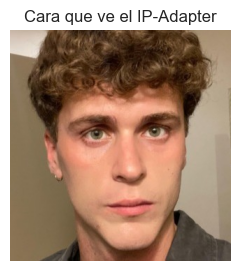

In [37]:
def recortar_cara(imagen_rgb, landmarks, margen: float = 0.35):
    h, w = imagen_rgb.shape[:2]
    xs = [lm.x * w for lm in landmarks]
    ys = [lm.y * h for lm in landmarks]
    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)
    mx, my = (x2 - x1) * margen, (y2 - y1) * margen
    x1, x2 = int(max(0, x1 - mx)), int(min(w, x2 + mx))
    y1, y2 = int(max(0, y1 - my)), int(min(h, y2 + my))
    return Image.fromarray(imagen_rgb[y1:y2, x1:x2])

cara_ref = recortar_cara(imagen, landmarks)

plt.figure(figsize=(3, 3))
plt.imshow(cara_ref)
plt.axis('off')
plt.title("Cara que ve el IP-Adapter")
plt.show()

Generamos el familiar con la configuración rápida de LCM: 8 pasos de inferencia y guidance 2.5, ya que con LCM-LoRA van pocos pasos (entre 4 y 8) y guidance bajo (entre 1.5 y 2.5). La cara recortada entra por el IP-Adapter a escala 0.45 y la seed determinista fija el resultado. Si el familiar sale humanoide conviene subir el guidance hacia 3, bajar el ip_scale hacia 0.4 y revisar el negative prompt. Y si no se pasa cara_ref, la función genera solo desde el texto.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (173 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['1 . 0 , ( delicate narrow face ) 0 . 9 , ( prominent little snout ) 0 . 9 , expressive fluffy brow tufts , a single small magical animal companion , gentle forest spirit familiar , full body , sitting , cute and huggable , big soft expressive eyes , soft rounded fluffy body , fluffy 

  0%|          | 0/8 [00:00<?, ?it/s]

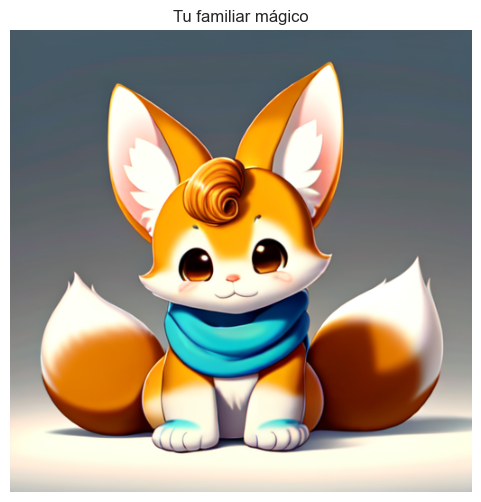

In [38]:
def generar_mascota(prompt: str, negative_prompt: str, seed: int,
                    cara_ref=None, ip_scale: float = None,
                    num_inference_steps: int = 8, guidance_scale: float = 2.5):
    if ip_scale is not None:
        pipe.set_ip_adapter_scale(ip_scale)

    generator = torch.Generator(device=device).manual_seed(seed)
    kwargs = dict(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
        width=512,
        height=512,
    )
    if cara_ref is not None:
        kwargs["ip_adapter_image"] = cara_ref
    return pipe(**kwargs).images[0]

mascota_img = generar_mascota(prompt, negative, seed, cara_ref=cara_ref)

plt.figure(figsize=(6, 6))
plt.imshow(mascota_img)
plt.axis('off')
plt.title("Tu familiar mágico")
plt.show()

Se visualiza la mascota generada. Como la seed se deriva del hash de los rasgos, si volvemos a correr la celda con los mismos rasgos obtenemos exactamente la misma criatura. Esto garantiza la identificabilidad ya que cada usuario tiene su mascota única y reproducible.

El warning de truncamiento indica que el text encoder de SD 1.5 solo procesa los primeros 77 tokens del prompt, por lo cual las frases con peso (la especie, el pelaje, el color de ojos y la magia) van al principio para que lo esencial entre antes del corte. La cola de estilo que se pierde queda cubierta en gran parte por el prior de CuteFurry que ya es de ilustración tierna.

## **9. Pipeline completo end-to-end**

Encapsulamos todas las etapas en una sola función de forma a poder llamar el sistema completo con una línea. Esto es lo que se conectará a la interfaz de demo, por ejemplo con Gradio. La función también acepta rasgos corregidos manualmente, así si ya pasaste por la UI de la sección 5.4 podés pasarle esos valores, que es lo que hacemos en la llamada de ejemplo.

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['1 . 0 , ( delicate narrow face ) 0 . 9 , ( prominent little snout ) 0 . 9 , expressive fluffy brow tufts , a single small magical animal companion , gentle forest spirit familiar , full body , sitting , cute and huggable , big soft expressive eyes , soft rounded fluffy body , fluffy cheeks , in a cozy magical forest with soft floating lights and dappled sunlight , soft painterly storybook illustration , gentle watercolor shading , warm dreamy light , soft focus background']


  0%|          | 0/8 [00:00<?, ?it/s]

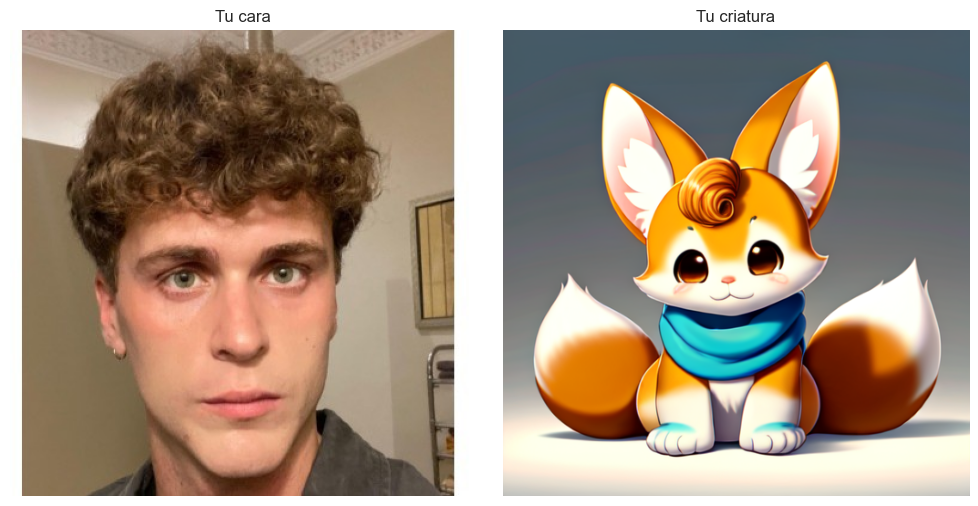


Seed única: 533606506

Trazabilidad por rasgo:
  color_pelo         = castano              [conf=0.33, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  textura_pelo       = rizado               [conf=0.52, fuentes: resnet_kat, vit_kat, agus, clip]
  longitud_pelo      = corto                [conf=0.42, fuentes: resnet_kat, vit_kat, agus, clip]
  cejas              = pobladas             [conf=0.26, fuentes: resnet_kat, vit_kat, agus, clip]
  forma_ojos         = redonda              [conf=0.27, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  tamano_nariz       = grande               [conf=0.48, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  forma_nariz        = recta                [conf=0.39, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  grosor_labios      = medianos             [conf=0.49, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  pomulos            = normales             [conf=0.34, fuentes: resnet_kat, vit_kat, agus, geometria, clip]
  ma

In [39]:
def pipeline_completo(imagen_rgb=None, ruta_archivo=None,
                      seed_override: int = None, mostrar: bool = True,
                      rasgos_corregidos_manualmente: dict = None,
                      ip_scale: float = None):
    if imagen_rgb is None and ruta_archivo is not None:
        imagen_rgb = cargar_desde_archivo(ruta_archivo)
    if imagen_rgb is None:
        imagen_rgb = capturar_webcam()
    if imagen_rgb is None:
        raise RuntimeError("No se pudo obtener una imagen de entrada.")

    res_mp = face_mesh.process(imagen_rgb)
    if not res_mp.multi_face_landmarks:
        raise RuntimeError("No se detectó ninguna cara en la imagen.")
    lm = res_mp.multi_face_landmarks[0].landmark

    rasgos_geom_local = extraer_rasgos_geometricos(imagen_rgb, lm)

    preds_probs_local = {}
    for nombre, modelo in modelos.items():
        preds_probs_local[nombre] = predecir_probabilidades(modelo, imagen_rgb)

    preds_clip_local = predecir_con_clip(imagen_rgb)

    rasgos_finales_local, confianzas_local, contribuciones_local = voto_suave_unificado(
        preds_probs_local, rasgos_geom_local, predicciones_clip=preds_clip_local
    )

    if rasgos_corregidos_manualmente:
        for rasgo, valor_nuevo in rasgos_corregidos_manualmente.items():
            if rasgo in rasgos_finales_local and rasgos_finales_local[rasgo] != valor_nuevo:
                rasgos_finales_local[rasgo] = valor_nuevo
                contribuciones_local[rasgo] = ['manual']
                confianzas_local[rasgo] = 1.0

    prompt_local, negative_local = construir_prompt(rasgos_finales_local, rgb_pelo=rasgos_geom_local.get('_color_pelo_rgb'), rgb_ojos=rasgos_geom_local.get('_color_ojos_rgb'))
    seed_local = seed_override if seed_override is not None else hash_a_seed(rasgos_finales_local)

    cara_ref_local = recortar_cara(imagen_rgb, lm)
    mascota_local = generar_mascota(
        prompt_local, negative_local, seed_local,
        cara_ref=cara_ref_local, ip_scale=ip_scale,
    )

    if mostrar:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(imagen_rgb)
        axes[0].axis('off')
        axes[0].set_title("Tu cara")
        axes[1].imshow(mascota_local)
        axes[1].axis('off')
        axes[1].set_title("Tu criatura")
        plt.tight_layout()
        plt.show()

    return {
        'rasgos':         rasgos_finales_local,
        'contribuciones': contribuciones_local,
        'confianzas':     confianzas_local,
        'prompt':         prompt_local,
        'negative':       negative_local,
        'seed':           seed_local,
        'cara_ref':       cara_ref_local,
        'mascota_img':    mascota_local,
    }

salida = pipeline_completo(
    imagen_rgb=imagen,
    rasgos_corregidos_manualmente=rasgos_finales,
)

print(f"\nSeed única: {salida['seed']}")
print(f"\nTrazabilidad por rasgo:")
for k, v in salida['rasgos'].items():
    conf = salida['confianzas'].get(k, 0)
    contrib = ', '.join(salida['contribuciones'].get(k, []))
    print(f"  {k:18s} = {str(v):20s} [conf={conf:.2f}, fuentes: {contrib}]")

La salida del pipeline contiene todo lo necesario para reproducir y auditar la generación: el diccionario de rasgos consolidados, la trazabilidad de qué fuente aportó cada uno, las confianzas del ensemble, el prompt completo, el negative prompt, la seed y la imagen final. Esto es útil para debug y para guardar registros en sistemas de producción.

## **Conclusiones**

El pipeline v15 mantiene el ensemble de cinco fuentes (los tres modelos preentrenados, la geometría con MediaPipe y CLIP como verificador externo) para describir los rasgos, suma una capa de corrección manual para garantizarlos antes de generar, y los lleva a un familiar mágico con tres ideas. Primero, elige un animalito real desde los rasgos (`arquetipo_animal`), de modo que el resultado se lea como un animal reconocible y varíe de persona a persona. Segundo, mete las formas detectadas (ojos, cara, nariz) en el prompt, que en versiones anteriores se descartaban. Tercero, integra la magia en el cuerpo del animal y condiciona coloración y expresión con la cara real vía IP-Adapter a escala baja.

Las limitaciones que persisten son tres. Primero, el parecido en un animal no humano tiene un techo: el IP-Adapter transfiere coloración y expresión más que estructura facial, así que el familiar se lee como inspirado en la persona, no como una réplica. Segundo, `IP_ADAPTER_SCALE`, el guidance y el peso de cada rasgo son hiperparámetros que conviene elegir a ojo según la foto. Tercero, el mapeo de rasgos a especie es una heurística razonable pero no validada; ampliar la paleta de animales y afinar qué rasgo elige cuál es el próximo paso natural.